In [1]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np


# Make plots render inline in the notebook
%matplotlib inline

def show_single_band(tif_path, band_idx=1, cmap='viridis', title=None):
    """Displays a single band from a TIF file inline."""
    print(f"Reading {tif_path}...")
    
    with rasterio.open(tif_path) as src:
        data = src.read(band_idx)
        
        # Handle nodata values so they don't mess up the colors
        if src.nodata is not None:
            data = np.where(data == src.nodata, np.nan, data)
        else:
            data = np.where((data <= -32000) | (data == 0), np.nan, data)

    plt.figure(figsize=(12, 10))
    
    # Apply robust contrast stretching (2nd to 98th percentile)
    vmin, vmax = np.nanpercentile(data, (2, 98))
    
    # Plot the image
    im = plt.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    
    # Add styling
    plt.colorbar(im, fraction=0.046, pad=0.04, label='Pixel Value')
    plt.title(title or f"Band {band_idx}")
    plt.axis('off')
    plt.show()


def show_rgb(tif_path, r_band=3, g_band=2, b_band=1, title=None):
    """Displays a true-color RGB composite from a TIF file inline."""
    print(f"Reading {tif_path}...")
    
    with rasterio.open(tif_path) as src:
        r = src.read(r_band).astype(float)
        g = src.read(g_band).astype(float)
        b = src.read(b_band).astype(float)
        
        mask = (r == 0) | (g == 0) | (b == 0)

    rgb = np.dstack((r, g, b))
    
    # Normalize each band for true-color contrast
    for i in range(3):
        band_data = rgb[:, :, i]
        valid_data = band_data[~mask]
        
        if len(valid_data) > 0:
            vmin, vmax = np.percentile(valid_data, (2, 98))
            rgb[:, :, i] = np.clip((band_data - vmin) / (vmax - vmin), 0, 1)
    
    rgb[mask] = 1.0  # Set nodata to white

    plt.figure(figsize=(12, 10))
    plt.imshow(rgb)
    plt.title(title or "RGB Composite")
    plt.axis('off')
    plt.show()

Reading /users/student/pg/pg23/akash.pal/SwanSAT_Assignment/data/satellite/S2_2024_11.tif...


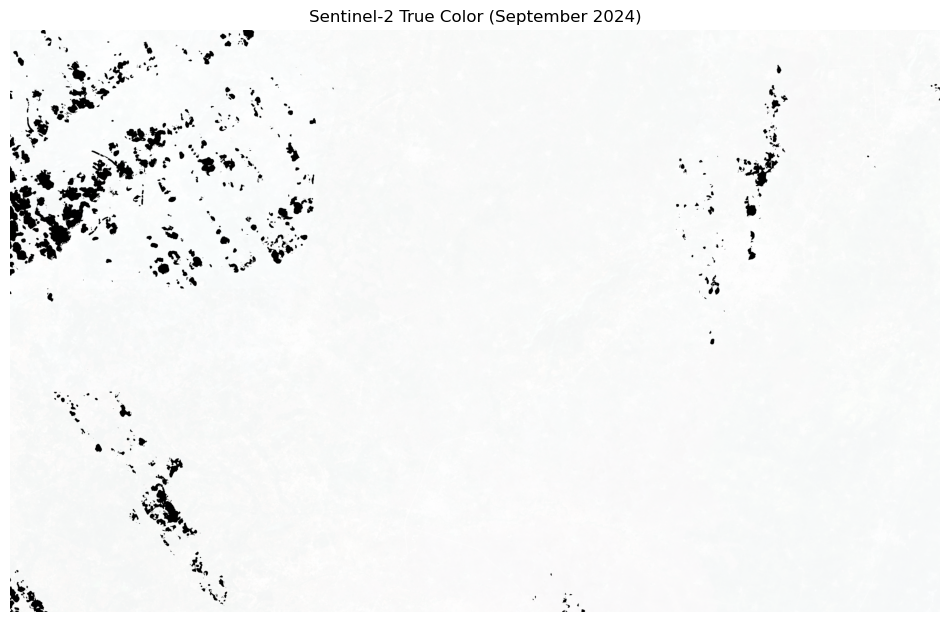

In [8]:
# B4(Red)=3, B3(Green)=2, B2(Blue)=1
show_rgb(
    '/users/student/pg/pg23/akash.pal/SwanSAT_Assignment/data/satellite/S2_2024_11.tif', 
    r_band=3, g_band=2, b_band=1, 
    title='Sentinel-2 True Color (September 2024)'
)

In [5]:
import rasterio
import numpy as np

for month in ['06','07','08','09','10','11']:
    with rasterio.open(f'data/satellite/S2_2024_{month}.tif') as src:
        data = src.read()  # (bands, H, W)
        # Check NDVI band (band 7, index 6)
        ndvi = data[6]
        nodata_pct = 100 * np.sum((ndvi == 0) | (ndvi == -32768)) / ndvi.size
        valid_pct = 100 - nodata_pct
        print(f"  S2 {month}: {valid_pct:.1f}% valid pixels, {nodata_pct:.1f}% nodata")

  S2 06: 97.1% valid pixels, 2.9% nodata
  S2 07: 26.4% valid pixels, 73.6% nodata
  S2 08: 30.8% valid pixels, 69.2% nodata
  S2 09: 59.8% valid pixels, 40.2% nodata
  S2 10: 99.1% valid pixels, 0.9% nodata
  S2 11: 97.7% valid pixels, 2.3% nodata


In [1]:
import rasterio

tif_path = 'data/satellite/S2_2024_10.tif'

with rasterio.open(tif_path) as src:
    print(f"Coordinate Reference System (CRS): {src.crs}")
    print(f"Image Bounds: \n{src.bounds}")

Coordinate Reference System (CRS): EPSG:4326
Image Bounds: 
BoundingBox(left=79.79995180266104, bottom=15.999983356981208, right=80.6000812262263, top=16.500434801764193)


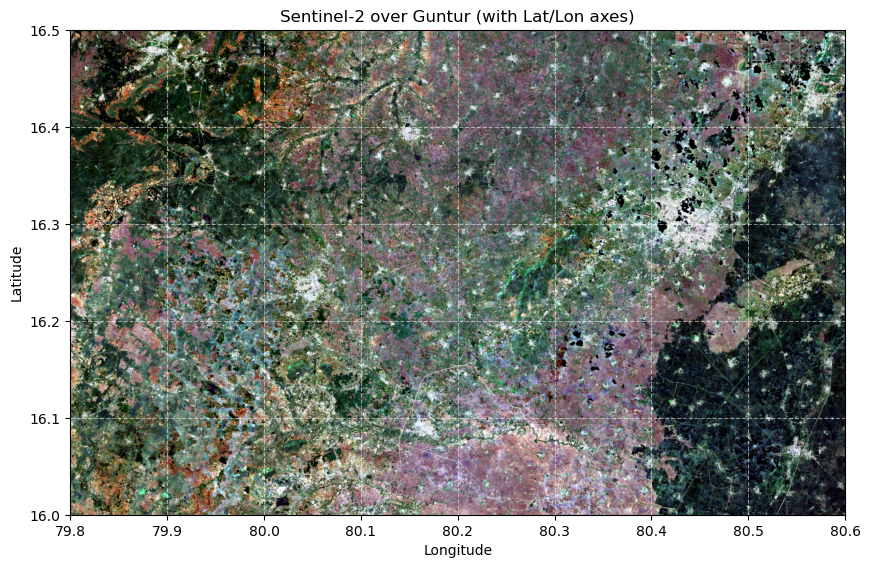

In [2]:
import rasterio
import matplotlib.pyplot as plt
import numpy as np

tif_path = 'data/satellite/S2_2024_10.tif'

with rasterio.open(tif_path) as src:
    # Read RGB bands
    r = src.read(3).astype(float)
    g = src.read(2).astype(float)
    b = src.read(1).astype(float)
    
    # Get the geographic boundaries
    bounds = src.bounds
    extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

# Stack and normalize
rgb = np.dstack((r, g, b))
for i in range(3):
    band = rgb[:, :, i]
    mask = band > 0
    if mask.any():
        vmin, vmax = np.percentile(band[mask], (2, 98))
        rgb[:, :, i] = np.clip((band - vmin) / (vmax - vmin), 0, 1)

plt.figure(figsize=(10, 8))
# Pass the 'extent' parameter to align pixels with real-world coordinates
plt.imshow(rgb, extent=extent) 
plt.title("Sentinel-2 over Guntur (with Lat/Lon axes)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid(color='white', linestyle='--', alpha=0.5)
plt.show()


In [3]:
import folium
import rasterio

tif_path = 'data/satellite/S2_2024_10.tif'

with rasterio.open(tif_path) as src:
    bounds = src.bounds

# Calculate the center of your image to center the map
center_lat = (bounds.bottom + bounds.top) / 2
center_lon = (bounds.left + bounds.right) / 2

# Create an interactive map
m = folium.Map(location=[center_lat, center_lon], zoom_start=10)

# Draw a rectangle representing your downloaded satellite data
folium.Rectangle(
    bounds=[[bounds.bottom, bounds.left], [bounds.top, bounds.right]],
    color='#ff0000',
    fill=True,
    fill_opacity=0.2,
    tooltip='Downloaded Satellite Data Extent'
).add_to(m)

# Display the map inline
m

Connecting to patches.npy (Memory Mapped)...
Total Array Shape: (21275, 6, 9, 64, 64)


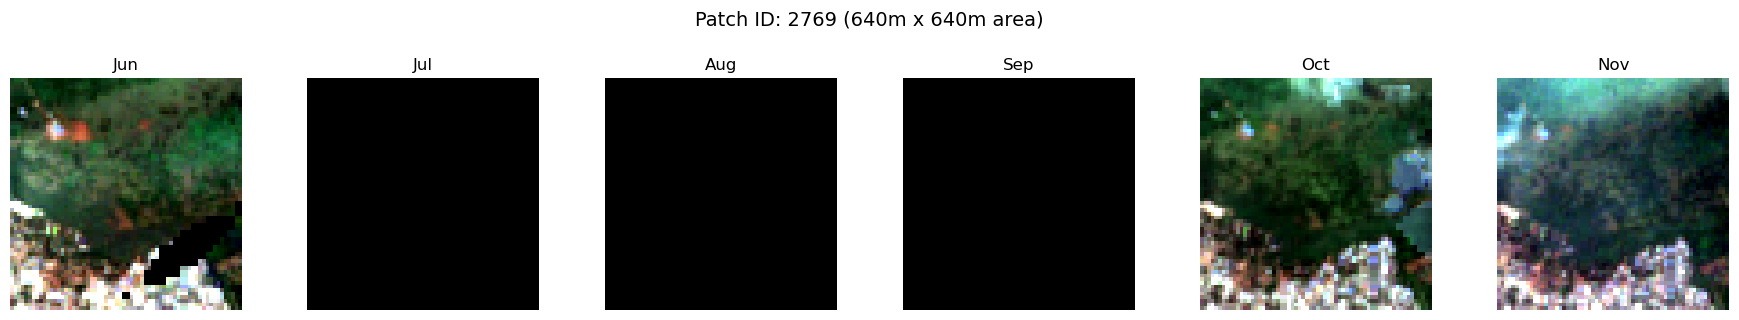

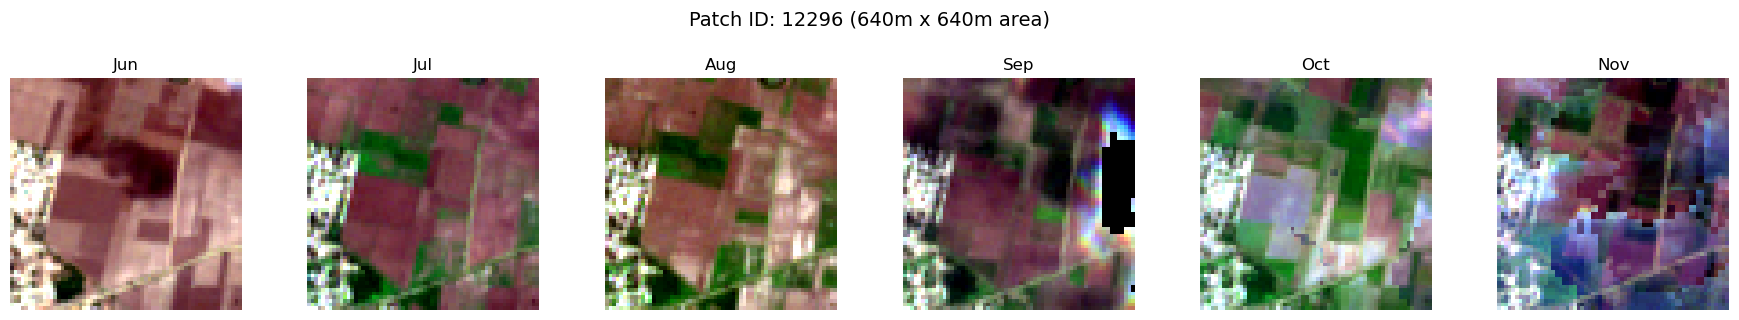

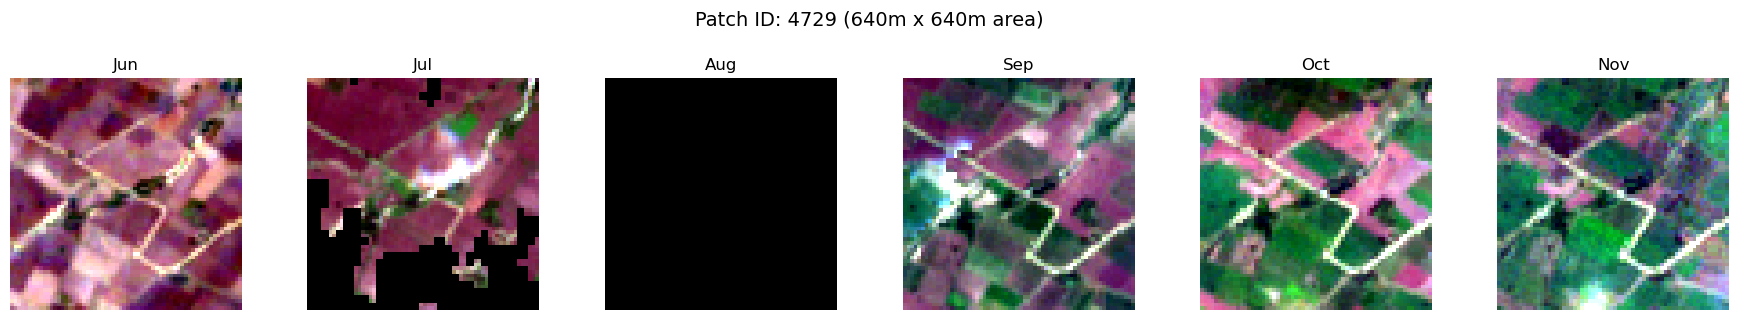

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make plots render inline in the notebook
%matplotlib inline

# 1. Load the massive file using Memory Mapping (Crucial to prevent crashing!)
print("Connecting to patches.npy (Memory Mapped)...")
patches = np.load('data/patches/patches.npy', mmap_mode='r')
print(f"Total Array Shape: {patches.shape}")

# 2. Select 3 random patches to look at
num_patches_to_view = 3
random_indices = np.random.choice(patches.shape[0], num_patches_to_view, replace=False)

months = ['Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov']

# 3. Plot them
for idx in random_indices:
    fig, axes = plt.subplots(1, 6, figsize=(18, 3))
    fig.suptitle(f"Patch ID: {idx} (640m x 640m area)", fontsize=14, y=1.05)
    
    for month_idx in range(6):
        # Extract the specific patch and month
        # Shape is (C, H, W) -> (9 bands, 64, 64)
        patch_data = patches[idx, month_idx]
        
        # Based on your download script, Optical bands are first:
        # B2 (Blue)=0, B3 (Green)=1, B4 (Red)=2
        r = patch_data[2]
        g = patch_data[1]
        b = patch_data[0]
        
        # Stack into an RGB image
        rgb = np.dstack((r, g, b))
        
        # Normalize the colors so it isn't too dark or blown out
        valid_pixels = rgb[rgb > 0]
        if len(valid_pixels) > 0:
            vmin, vmax = np.percentile(valid_pixels, (2, 98))
            rgb_norm = np.clip((rgb - vmin) / (vmax - vmin), 0, 1)
        else:
            # If the patch is entirely blank (e.g., masked out by clouds)
            rgb_norm = np.zeros_like(rgb)
            
        axes[month_idx].imshow(rgb_norm)
        axes[month_idx].set_title(months[month_idx])
        axes[month_idx].axis('off')
        
    plt.tight_layout()
    plt.show()